In [2]:
import json
import pandas as pd

with open('Timeline.json','r', encoding='utf-8') as data:
    datos = json.load(data)

print("Estructura principal:", datos.keys())

df=pd.json_normalize(datos['semanticSegments'])
df_visitas = df.dropna(subset=['visit.topCandidate.placeId']).copy()
df_actividades = df.dropna(subset=['activity.topCandidate.type']).copy()

print(f"Total de visitas registradas: {len(df_visitas)}")
print(f"Total de actividades registradas: {len(df_actividades)}")

display(df.head())

Estructura principal: dict_keys(['semanticSegments', 'rawSignals', 'userLocationProfile'])
Total de visitas registradas: 2998
Total de actividades registradas: 3464


,startTime,endTime,timelinePath,startTimeTimezoneUtcOffsetMinutes,endTimeTimezoneUtcOffsetMinutes,visit.hierarchyLevel,visit.probability,visit.topCandidate.placeId,visit.topCandidate.semanticType,visit.topCandidate.probability,...,activity.end.latLng,activity.distanceMeters,activity.probability,activity.topCandidate.type,activity.topCandidate.probability,activity.parking.location.latLng,activity.parking.startTime,visit.isTimelessVisit,timelineMemory.trip.distanceFromOriginKms,timelineMemory.trip.destinations
0,2025-04-04T22:00:00.000-03:00,2025-04-05T00:00:00.000-03:00,"[{'point': '-34.7173411°, -58.4094101°', 'time...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-04T22:01:24.000-03:00,2025-04-06T12:01:13.000-03:00,NaN,-180.0,-180.0,0.0,0.452601,ChIJdRmmBA_NvJUROcvrtFw5aqI,UNKNOWN,0.256845,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-05T00:00:00.000-03:00,2025-04-05T02:00:00.000-03:00,"[{'point': '-34.7173704°, -58.4094521°', 'time...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-04-06T12:00:00.000-03:00,2025-04-06T14:00:00.000-03:00,"[{'point': '-34.7320946°, -58.3663463°', 'time...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04-06T12:01:13.000-03:00,2025-04-06T15:27:23.000-03:00,NaN,-180.0,-180.0,0.0,0.968866,ChIJ5zQgH6oyo5UR1ZFL3oUlYgc,UNKNOWN,0.375224,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
import json
import pandas as pd

with open('Timeline.json','r', encoding='utf-8') as data:
    datos = json.load(data)
    print("Estructura principal:", datos.keys())

df=pd.json_normalize(datos['semanticSegments'])
df_visitas = df.dropna(subset=['visit.topCandidate.placeId']).copy()
df_actividades = df.dropna(subset=['activity.topCandidate.type']).copy()

#define una  lista con las columnas a conservar
columnas_utiles = [
    'startTime', 'endTime', 'visit.topCandidate.placeId', 'visit.topCandidate.semanticType'
]
df_visitas_util = df_visitas[columnas_utiles].copy()

df_visitas_util.columns = ['inicio', 'fin', 'place_id', 'tipo_lugar']

df_visitas_util['inicio']=pd.to_datetime(df_visitas_util['inicio'])
df_visitas_util['fin']=pd.to_datetime(df_visitas_util['fin'])

#print(df_visitas_util.dtypes)
#display(df_visitas_util.head())

#calcula la duracion de cada visita
df_visitas_util['duracion']=df_visitas_util['fin'] - df_visitas_util['inicio']

df_visitas_util['mes_anio']=df_visitas_util['inicio'].dt.to_period('M')

df_visitas_util['dia_sem']=df_visitas_util['inicio'].dt.weekday

df_visitas_util['esFinSem']=df_visitas_util['dia_sem']>=5

display(df_visitas_util.head())

Estructura principal: dict_keys(['semanticSegments', 'rawSignals', 'userLocationProfile'])


C:\Users\gabig\AppData\Local\Temp\ipykernel_3544\1816040958.py:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_visitas_util['mes_anio']=df_visitas_util['inicio'].dt.to_period('M')


,inicio,fin,place_id,tipo_lugar,duracion,mes_anio,dia_sem,esFinSem
1,2025-04-04 22:01:24-03:00,2025-04-06 12:01:13-03:00,ChIJdRmmBA_NvJUROcvrtFw5aqI,UNKNOWN,1 days 13:59:49,2025-04,4,False
4,2025-04-06 12:01:13-03:00,2025-04-06 15:27:23-03:00,ChIJ5zQgH6oyo5UR1ZFL3oUlYgc,UNKNOWN,0 days 03:26:10,2025-04,6,True
7,2025-04-06 15:34:02-03:00,2025-04-06 17:13:53-03:00,ChIJf7aONkjNvJURrAIeUyaagWQ,UNKNOWN,0 days 01:39:51,2025-04,6,True
10,2025-04-06 17:27:37-03:00,2025-04-07 10:19:45-03:00,ChIJdRmmBA_NvJUROcvrtFw5aqI,UNKNOWN,0 days 16:52:08,2025-04,6,True
15,2025-04-09 11:43:22-03:00,2025-04-09 11:47:34-03:00,ChIJPbtP4lfKvJURDPKYCQYlUnw,WORK,0 days 00:04:12,2025-04,2,False


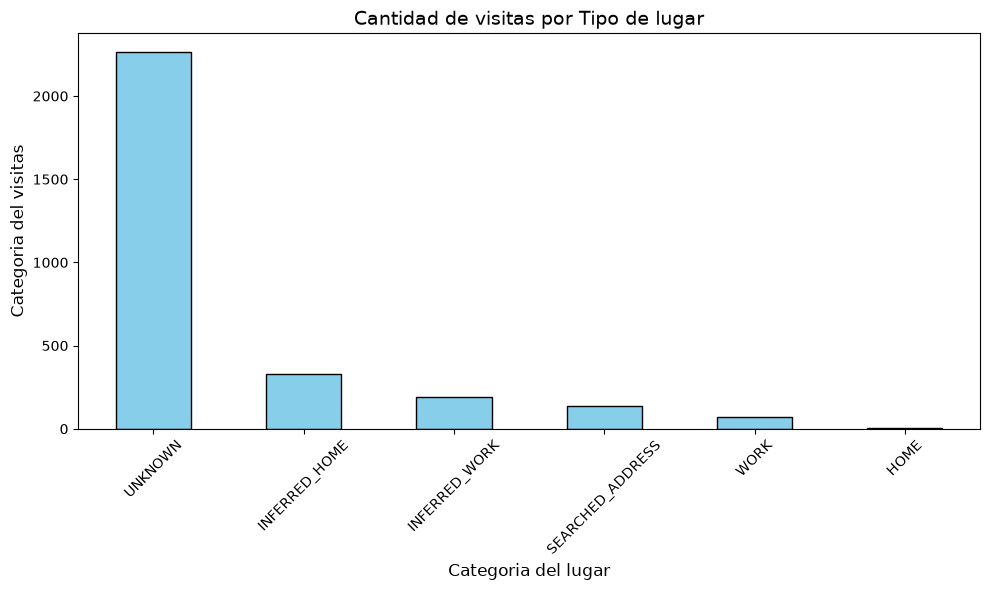

In [4]:
import matplotlib.pyplot as plt

count_lugares=df_visitas_util['tipo_lugar'].value_counts()

plt.figure(figsize=(10,6))

count_lugares.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Cantidad de visitas por Tipo de lugar', fontsize=14)
plt.xlabel('Categoria del lugar', fontsize=12)
plt.ylabel('Categoria del visitas', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# Buscamos columnas en el dataset original que contengan palabras clave de ubicación
columnas_ubicacion = [
    col for col in df_visitas.columns 
    if ('lat' in col.lower() or 'lng' in col.lower() or 'location' in col.lower()) and 'visit' in col
]

print("Columnas de ubicación disponibles en tu JSON:")
for col in columnas_ubicacion:
    print(col)

Columnas de ubicación disponibles en tu JSON:
visit.topCandidate.placeLocation.latLng


In [6]:
import folium
df_visitas_util['coordenadas'] = df_visitas['visit.topCandidate.placeLocation.latLng']

#convierte a texto y separa lat de long
coords = df_visitas_util['coordenadas'].astype(str).str.replace('°','',regex=False)
df_visitas_util[['latitud','longitud']] = coords.str.split(',',expand=True)

#convierte a numeros reales
df_visitas_util['latitud']=pd.to_numeric(df_visitas_util['latitud'], errors='coerce')
df_visitas_util['longitud']=pd.to_numeric(df_visitas_util['longitud'], errors='coerce')

#crear dataset solo con UNKNOWN
lug_unknown=df_visitas_util[df_visitas_util['tipo_lugar']=='UNKNOWN'].copy()
lug_unicos = lug_unknown.drop_duplicates(subset=['place_id']).dropna(subset=['latitud','longitud'])
print(f"se mapearan {len(lug_unicos)} lugares unicos desconocidos")

#crea mapa interactivo centrado en coord
centro_lat = lug_unicos['latitud'].mean()
centro_lon = lug_unicos['longitud'].mean()
mapa = folium.Map(location=[centro_lat,centro_lon], zoom_start=13)

#agrega puntos
for i, fila in lug_unicos.iterrows():
    folium.Marker(
        location=[fila['latitud'],fila['longitud']],
        popup=f"Place ID: {fila['place_id']}", #muestra el id
        icon=folium.Icon(color='red', icon='question-sign')
    ).add_to(mapa)

mapa

se mapearan 543 lugares unicos desconocidos


In [7]:
import numpy as np
import folium
#haversine
def calcular_distancia(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2)**2
    return R * (2 * np.arctan2(np.sqrt(a), np.sqrt(1-a)))
#diccionario marcadores
mis_lugares = {
    "Casa abuelos": ("ChIJa9k_n1rMvJURmFjEVhsJ6zE",300),
    "Casa madre": ("ChIJGyE07OWvvJURl7eJv0HA6T0",300),
    "Casa lau": ("ChIJh4ZK0FfLvJURIjsYSB7jdIo",300),
    "Casa tio": ("ChIJA0wrqlkyo5URqe1Pu7Ur7OI",100),
    "Casa ailen": ("ChIJu2MiH0Myo5URUyUTCLsKSk0",100),
    "Casa brisa": ("ChIJTZBVwETNvJURvZ8tXq-6p6M",100),
    "Casa gonza": ("ChIJg78vSkjNvJURl-c_xlIaoTM",100),
    "Casa pablo": ("ChIJ4f09BKoyo5URRI4Km8H2xVY",100),
    "casa santi": ("ChIJ39J_P0bNvJURlfoGW4ksUyk",100),
    "Casa cami": ("ChIJs3Cx8D3NvJURjlzElHq9YH4",100),
    "Casa marco": ("ChIJZ9nEQRzTvJURtFjGaN7BZDc",100),
    "Casa ema": ("ChIJlZhJERPKvJURYn4VfkUmKKw",100),
    "Barberia": ("ChIJD8SQF5DNvJURNtxm8W6eG0I",100),
    "Barberia nuevo": ("ChIJNZVAFz3NvJURIMwHZK8FMWM",100),
    "Bares Lanusita": ("ChIJ82zSNSDNvJURrmVwXbm3KHI",250),
    "Restaurantes Av Corrientes": ("ChIJJ6UiqcbKvJUR4nxYpnMR9wI",100),
    "Alto Avellaneda": ("ChIJr_ghSDQzo5UReewoaZ_HDkA",300),
    "DOT": ("ChIJiXqyScC2vJURa7eDXB_4r7Q",200),
    "Unicenter": ("ChIJD5Ao3PGwvJURy5vWbS2FIPc",200),
    "Norcenter": ("ChIJVy69HemwvJURalkkK078b1s",200),
    "Decathlon": ("ChIJP1wTjb23vJUR8LKQ7r1topw",100),
    "Monumental": ("ChIJ340B5jq0vJURijD6W6dgfz0",100),
    "Aeroparque": ("ChIJtccx9ae1vJUR28qcL4mS2f0",100),
    "Punta Carrasco": ("ChIJXeE7t2y1vJURibKLauqO330",100),
    "Trabajo Teatro Colon": ("ChIJIxYSMMbKvJURqZGJyCpvOFM",100),
    "Trabajo BBVA": ("ChIJNQWOvzQ1o5URDBWv93Fy7E8",100),
    "Trabajo Macro": ("ChIJuZ28VzU1o5UR3yrH7JyU3FM",100),
    "Trabajo Columbia": ("ChIJ24SkTC01o5URdHUB2LRUb_c",100),
    "Trabajo Galicia": ("ChIJPaop8M3KvJURbpDWE-rnX6c",100),
    "Trabajo BNA": ("ChIJk3U0KS01o5URsofTDnwrNbI",100),
    "Trabajo ICBC": ("ChIJS3xrUQDLvJURe9s1sM8yrao",100),
    "Trabajo Supervielle": ("ChIJocgARc3KvJURnPRTacWXgyw",100),
    "Trabajo Santander": ("ChIJS8u27s00o5UR9dtpsV0MFkM",100),
    "Trabajo Patagonia": ("5b1MtLKvJUR_MRYyAEgpow",100),
    "Parque de la Costa": ("ChIJ8yqtk7ClvJUR4IPSej94zk8",300)
}

for nombre, (place_id, radio_metros) in mis_lugares.items():
    
    coincidencias = lug_unicos[lug_unicos['place_id'] == place_id]
    
    if not coincidencias.empty:
        centro = coincidencias.iloc[0]
        lat_centro, lon_centro = centro['latitud'], centro['longitud']
        
        # Filtra usando el radio específico de ESTE lugar
        distancia = calcular_distancia(
            lat_centro, lon_centro, 
            df_visitas_util['latitud'], df_visitas_util['longitud']
        )
        
        dentro_del_radio = distancia <= radio_metros
        df_visitas_util.loc[dentro_del_radio, 'tipo_lugar'] = nombre
        
        # Dibuja el círculo con el radio específico
        folium.Circle(
            location=[lat_centro, lon_centro],
            radius=radio_metros,
            color='blue', fill=True, fill_opacity=0.3,
            popup=f'{nombre} ({radio_metros}m)'
        ).add_to(mapa)
        
        print(f"✅ {nombre} (Radio {radio_metros}m): Se agruparon {dentro_del_radio.sum()} visitas.")
    else:
        print(f"⚠️ {nombre}: No se encontró ese Place ID.")

# 4. Mostrar el mapa
mapa



✅ Casa abuelos (Radio 300m): Se agruparon 113 visitas.
✅ Casa madre (Radio 300m): Se agruparon 73 visitas.
✅ Casa lau (Radio 300m): Se agruparon 8 visitas.
✅ Casa tio (Radio 100m): Se agruparon 9 visitas.
✅ Casa ailen (Radio 100m): Se agruparon 3 visitas.
✅ Casa brisa (Radio 100m): Se agruparon 9 visitas.
✅ Casa gonza (Radio 100m): Se agruparon 21 visitas.
✅ Casa pablo (Radio 100m): Se agruparon 39 visitas.
✅ casa santi (Radio 100m): Se agruparon 7 visitas.
✅ Casa cami (Radio 100m): Se agruparon 12 visitas.
✅ Casa marco (Radio 100m): Se agruparon 1 visitas.
✅ Casa ema (Radio 100m): Se agruparon 5 visitas.
✅ Barberia (Radio 100m): Se agruparon 63 visitas.
✅ Barberia nuevo (Radio 100m): Se agruparon 13 visitas.
✅ Bares Lanusita (Radio 250m): Se agruparon 19 visitas.
✅ Restaurantes Av Corrientes (Radio 100m): Se agruparon 3 visitas.
✅ Alto Avellaneda (Radio 300m): Se agruparon 40 visitas.
✅ DOT (Radio 200m): Se agruparon 6 visitas.
✅ Unicenter (Radio 200m): Se agruparon 6 visitas.
✅ Norce

In [8]:
#exportar dataframe a csv
df_visitas_util.to_csv('Timeline_procesado.csv', index=False, encoding='utf-8')

print("Done")

Done
